In [1]:
import numpy as np
from desc.geometry import FourierRZToroidalSurface
from desc.utils import rpz2xyz, dot
from desc.grid import LinearGrid
from desc.magnetic_fields import SourceFreeField
from desc.coils import FourierRZCoil, CoilSet
import matplotlib.pyplot as plt
import jax
from desc.backend import jnp
from desc.batching import vmap_chunked
from scipy.constants import mu_0

from desc.integrals.singularities import (
    _G,
    _grad_G,
    _kernel_BS_plus_grad_S,
    _kernel_nr_over_r3,
)

import os

maxiter = 30
chunk_size = 1000

# Define surface
R0 = 2
aspect_ratio = 2
NFP = 2
a = R0/aspect_ratio
surface = FourierRZToroidalSurface.from_shape_parameters(
    major_radius=R0,
    aspect_ratio=aspect_ratio,
    elongation=1,
    triangularity=0,
    squareness=0,
    eccentricity=0,
    torsion=0,
    twist=0,
    NFP=1,
    sym=True,
)
assert surface.NFP == 1

# Define poloidal and toroidal resolution
M = N = 32
grid = LinearGrid(M=M, N=N)

# Compute on-surface data
data_keys = ["x", "n_rho", "a"]
data = surface.compute(data_keys, grid=grid, basis="xyz")

# Compute an offset surface that should be in \mathcal{X} and therefore grad(phi) = B
"""offset_surface, offset_data, info = surface.constant_offset_surface(
    0.1, grid=grid, M=grid.M, N=grid.N
)"""

offset_surface = FourierRZToroidalSurface.from_shape_parameters(
    major_radius=R0,
    aspect_ratio=R0/(data["a"] + 0.1),
    elongation=1,
    triangularity=0,
    squareness=0,
    eccentricity=0,
    torsion=0,
    twist=0,
    NFP=1,
    sym=True,
)



field_type = "coil"

if field_type == "greens_function":
    # This field type corresponds to a magnetic monopole
    # It's the field used in Kaya's original test
    # But it's not physical
    x0 = rpz2xyz(np.array([R0, 0, 0]))
    B = _grad_G(data["x"] - x0)
elif field_type == "coil":
    # The field type should be a quadrupole, 
    # since it is two currents with opposing sign
    # This also means there should be no net current in ~\mathcal{X}
    # So there are no secular terms in \Phi
    I = 1e6
    coil1 = FourierRZCoil(current=I, R_n=[R0], Z_n=[data["a"] / 2], NFP=1)
    coil2 = FourierRZCoil(current=-I, R_n=[R0], Z_n=[-data["a"] / 2], NFP=1)
    coil = CoilSet([coil1, coil2])

    B = coil.compute_magnetic_field(data["x"], source_grid=LinearGrid(N=grid.N), basis="xyz")

B_dot_n = dot(B, data["n_rho"])
data = {"B0*n": -B_dot_n}

field = SourceFreeField(surface, grid.M, grid.N)
fname = f"{field_type}_M_{grid.M}_N_{grid.N}_phi.npz"
override = True
if os.path.isfile(fname) and not override:
    data = np.load(fname)
else:
    data, RpZ_data = field.compute(
        ["∇φ", "Phi", "x", "n_rho"],
        grid,
        data=data,
        problem="exterior Neumann ",
        on_boundary=True,
        maxiter=maxiter,
        full_output=True,
        chunk_size=chunk_size,
        basis="xyz",
    )
    assert data is RpZ_data
    print("num iterations:", data["num iter"])
    print("Phi error     :", data["Phi error"])

np.testing.assert_allclose(
    data["∇φ"],
    B,
    atol=1e-6,
)
np.savez(fname, **data)

num iterations: 25
Phi error     : 9.009717122365757e-08


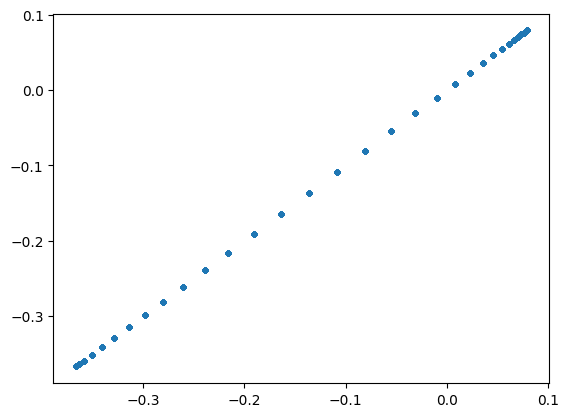

In [3]:
# Check that the matrix gives the same thing as the fixed point iteration
save_path = "results/phi_matrix/"
fname = f"M_{grid.M}_N_{grid.N}_phi_matrix.npy"
phi_matrix = np.load(save_path + fname)
plt.plot(data["Phi"], phi_matrix @ B_dot_n, linestyle = "", marker=".")
np.testing.assert_allclose(data["Phi"], phi_matrix @ B_dot_n, rtol=1e-05, atol=1e-08)

In [6]:
# Check that B_dot_n gives the correct vacuum energy
surface_jacobian = surface.compute("|e_theta x e_zeta|", grid=grid, basis="xyz")["|e_theta x e_zeta|"]
full_matrix = (
    1
    / (2 * mu_0)
    * (-phi_matrix) # SWAP OUT LATER NOW THAT SIGN CONVENTION IS SWAPPED IN MAIN CODE
    * (surface_jacobian[:, None] * grid.weights[:, None])
)
a = surface.compute(["a"], grid=grid, basis="xyz")["a"]

surf_jacobian = a * (R0 + a * np.cos(grid.nodes[:,1])) * grid.weights

# Vacuum energy 
W_phi = (1 / (2 * mu_0)) * (data["Phi"] * data["B0*n"] * surf_jacobian).sum()
np.testing.assert_allclose(B_dot_n.T @ full_matrix @ B_dot_n, W_phi)

/Users/maya/Desktop/DESC/desc/utils.py:572: UserWarning: Current on axis is nonzero, got -3.151e-08 Amps
  warnings.warn(msg, err)


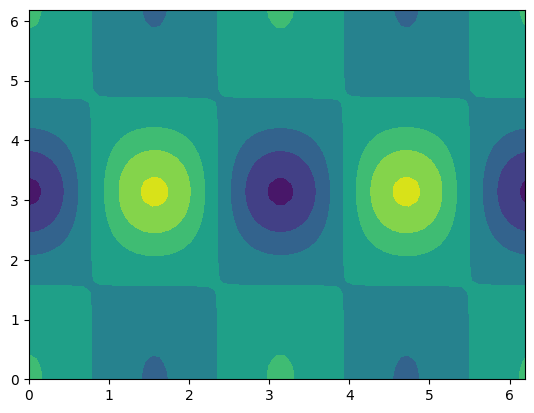

In [ ]:
from desc.equilibrium import Equilibrium
from desc.profiles import PowerSeriesProfile
from desc.basis import DoubleFourierSeries
from desc.transform import Transform

# Equilibrium
I_mult = 1
I_coeffs = np.array([-3.15111573e-08,  7.16194786e+03,  7.95861633e+02,  7.95781352e+02,
-1.19289606e-02, -3.19292792e-03, -4.34680863e-03])
I_coeffs = I_coeffs * I_mult
I_profile = PowerSeriesProfile(I_coeffs, sym=True)
iota_coeffs = None
iota_profile = None
p_coeffs = np.array([0.125, 0, 0, 0, -0.125])
p_profile = PowerSeriesProfile(p_coeffs)

eq = Equilibrium(
        L=12,
        M=12,
        N=0,
        surface=surface,
        NFP=surface.NFP,
        iota = iota_profile,
        current=I_profile,
        pressure=p_profile,
        Psi=1,
    )

# Toy trial function
xi_sup_rho = np.cos(grid.nodes[:,1]) * np.sin(2 * grid.nodes[:,2])
data = eq.compute(["psi_r","sqrt(g)_PEST","g^rr", "iota"], grid=grid, basis="xyz")
psi_r = data["psi_r"]
sqrtg_grad_rho = (data["sqrt(g)_PEST"] * np.sqrt(data["g^rr"]))
iota = data["iota"]

# Actually compute Bdotn
basis = DoubleFourierSeries(grid.M, grid.N)
transform = Transform(grid, basis, derivs=1,build_pinv=True)
xi_c = transform.fit(xi_sup_rho)

# xi derivatives
xi_sup_rho_t = transform.transform(xi_c, dt=1)
xi_sup_rho_z = transform.transform(xi_c, dz=1)

B_dot_n = psi_r/sqrtg_grad_rho * (iota * xi_sup_rho_t + xi_sup_rho_z)
plt.contourf(grid.nodes[:,2].reshape(grid.num_zeta, grid.num_theta), grid.nodes[:,1].reshape(grid.num_zeta, grid.num_theta), B_dot_n.reshape(grid.num_zeta, grid.num_theta))

In [23]:
from desc.diffmat_utils import DiffMat, legendre_diffmat, fourier_diffmat
import jax


# Copied from Rahul's code
def _cT(x):
    return jnp.conjugate(jnp.transpose(x))


D_theta0, W_theta = fourier_diffmat(grid.num_theta)
D_zeta0, W_zeta = fourier_diffmat(grid.num_zeta)
n_rho_max = 1
n_theta_max = D_theta0.shape[0]
n_zeta_max = D_zeta0.shape[0]

# TEMPORARY BECAUSE THIS IS HOW THE GRID WAS ORIGINALLY MADE
# RAHUL'S CONVENTION IS OPPOSITE
I_theta0 = jax.lax.stop_gradient(jnp.eye(n_theta_max))
I_zeta0 = jax.lax.stop_gradient(jnp.eye(n_zeta_max))

D_theta = jax.lax.stop_gradient(jnp.kron(I_zeta0, D_theta0))
D_zeta = jax.lax.stop_gradient(jnp.kron(D_zeta0, I_theta0))

D_thetaT = jax.lax.stop_gradient(jnp.kron(I_zeta0,_cT(D_theta0)))
D_zetaT = jax.lax.stop_gradient((jnp.kron(_cT(D_zeta0), I_theta0)))

W = jnp.diag(jnp.kron(W_theta, W_zeta))[:, None]

psi_r = data["psi_r"][:, None]
sqrtg_grad_rho = (data["sqrt(g)_PEST"] * np.sqrt(data["g^rr"]))[:, None]
iota = data["iota"][:, None]

#
full_xi_matrix = (
    1
    / (2 * mu_0)
    * _cT(W * psi_r * (iota * D_theta + D_zeta))
    @ (-phi_matrix @ (psi_r / sqrtg_grad_rho * (iota * D_theta + D_zeta)))
)
np.testing.assert_allclose(B_dot_n.T @ full_matrix @ B_dot_n, xi_sup_rho.T @ full_xi_matrix @ xi_sup_rho)
# It's not Hermitian; should I expect that?
np.testing.assert_allclose(full_xi_matrix, _cT(full_xi_matrix))

AssertionError: 
Not equal to tolerance rtol=1e-07, atol=0

Mismatched elements: 17541680 / 17850625 (98.3%)
Max absolute difference among violations: 0.04502934
Max relative difference among violations: 3722.58526852
 ACTUAL: array([[ 2.826043e+03,  8.834740e+02,  2.561566e+02, ..., -2.696252e+01,
        -6.289843e+01, -4.100753e+02],
       [ 8.834740e+02,  2.828585e+03,  8.835254e+02, ...,  7.619116e+00,...
 DESIRED: array([[ 2.826043e+03,  8.834740e+02,  2.561565e+02, ..., -2.696259e+01,
        -6.289839e+01, -4.100754e+02],
       [ 8.834740e+02,  2.828585e+03,  8.835255e+02, ...,  7.619213e+00,...

In [27]:
data = {"B0*n": -B_dot_n}

field = SourceFreeField(surface, grid.M, grid.N)
fname = f"{field_type}_M_{grid.M}_N_{grid.N}_phi.npz"
override = True
if os.path.isfile(fname) and not override:
    data = np.load(fname)
else:
    data, RpZ_data = field.compute(
        ["∇φ", "Phi", "x", "n_rho"],
        grid,
        data=data,
        problem="exterior Neumann ",
        on_boundary=True,
        maxiter=maxiter,
        full_output=True,
        chunk_size=chunk_size,
        basis="xyz",
    )
    assert data is RpZ_data
    print("num iterations:", data["num iter"])
    print("Phi error     :", data["Phi error"])

W_phi = (1 / (2 * mu_0)) * (data["Phi"] * data["B0*n"] * surf_jacobian).sum()

np.testing.assert_allclose(W_phi, xi_sup_rho.T @ full_xi_matrix @ xi_sup_rho)

num iterations: 25
Phi error     : 8.940696794024205e-08


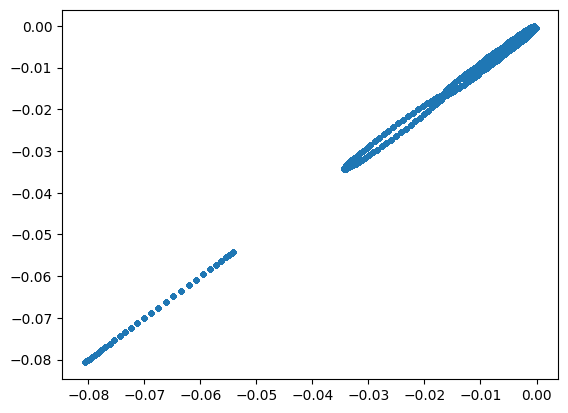

In [25]:
plt.plot(phi_matrix.flatten(), phi_matrix.T.flatten(), linestyle='', marker=".")

In [28]:
from desc.equilibrium.coords import map_coordinates

# The grid was also made in regular rho, theta, zeta, whereas the code needs PEST coords to work
# This double-checks it's the same for a circular tokamak
coords_pest = map_coordinates(
    eq,
    grid.nodes,
    inbasis=("rho", "theta", "zeta"),
    outbasis=("rho", "theta_PEST", "zeta"),
)
np.testing.assert_allclose(coords_pest, grid.nodes)

# Differentiation matrices work as expected
np.testing.assert_allclose(D_theta @ xi_sup_rho, xi_sup_rho_t, atol=1E-10)
np.testing.assert_allclose(D_zeta @ xi_sup_rho, xi_sup_rho_z, atol=1E-10)

In [29]:
# Check that B_dot_n gives the same as the B_dot_n matrix
np.testing.assert_allclose(
    psi_r / sqrtg_grad_rho * (iota * D_theta + D_zeta) @ xi_sup_rho, B_dot_n
)

In [31]:
# This is the matrix such that W_V = B_dot_n @ matrix @ B_dot_n
full_matrix = (
    1
    / (2 * mu_0)
    * (-phi_matrix) # SWAP OUT LATER NOW THAT SIGN CONVENTION IS SWAPPED IN MAIN CODE
    * (data["|e_theta x e_zeta|"][:, None] * grid.weights[:, None])
)

In [32]:
"""field = SourceFreeField(surface, grid.M, grid.N)
data, RpZ_data  = field.compute(["interpolator", "x", "n_rho", "potential data"], grid)
def phi_func(B_n):
    data_cp = data.copy()
    data_cp["B0*n"] = -B_n
    data_cp, RpZ_data = field.compute(
        ["Phi"],
        grid,
        data=data_cp,
        problem="exterior Neumann ",
        on_boundary=True,
        maxiter=maxiter,
        full_output=True,
        chunk_size=chunk_size,
        basis="xyz",
    )
    return data_cp["Phi"]


Phi_mat = vmap_chunked(phi_func, chunk_size=50)(jnp.eye(grid.num_nodes))
"""
data, _ = field.compute(
    ["phi_matrix"],
    grid,
    data=data,
    problem="exterior Neumann",
    chunk_size=chunk_size,
)
phi_matrix = -data["phi_matrix"]



: 

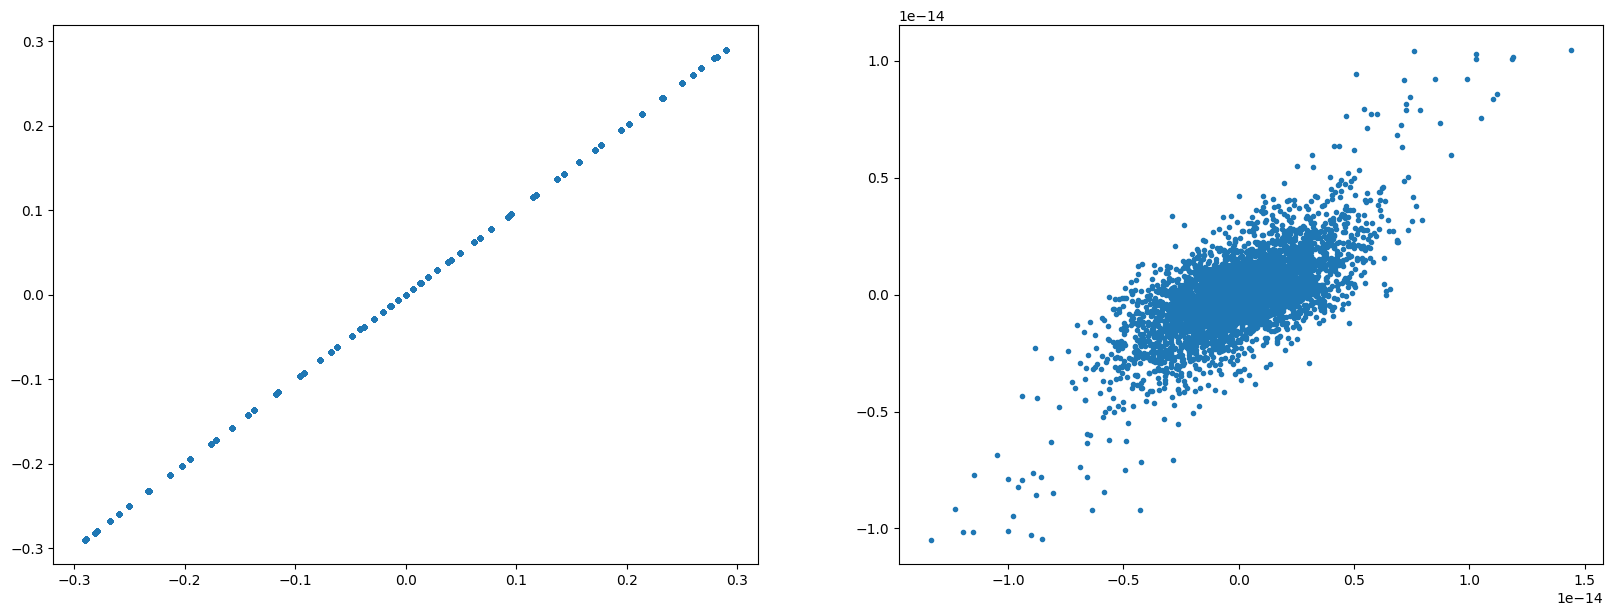

In [2]:
fig,ax = plt.subplots(1,2,figsize=(20,7))
ax[0].plot(data["Phi_t (periodic)"], dot(B, data["e_theta"]), linestyle="None", marker='.')
ax[1].plot(data["Phi_z (periodic)"], dot(B, data["e_zeta"]), linestyle="None", marker='.')

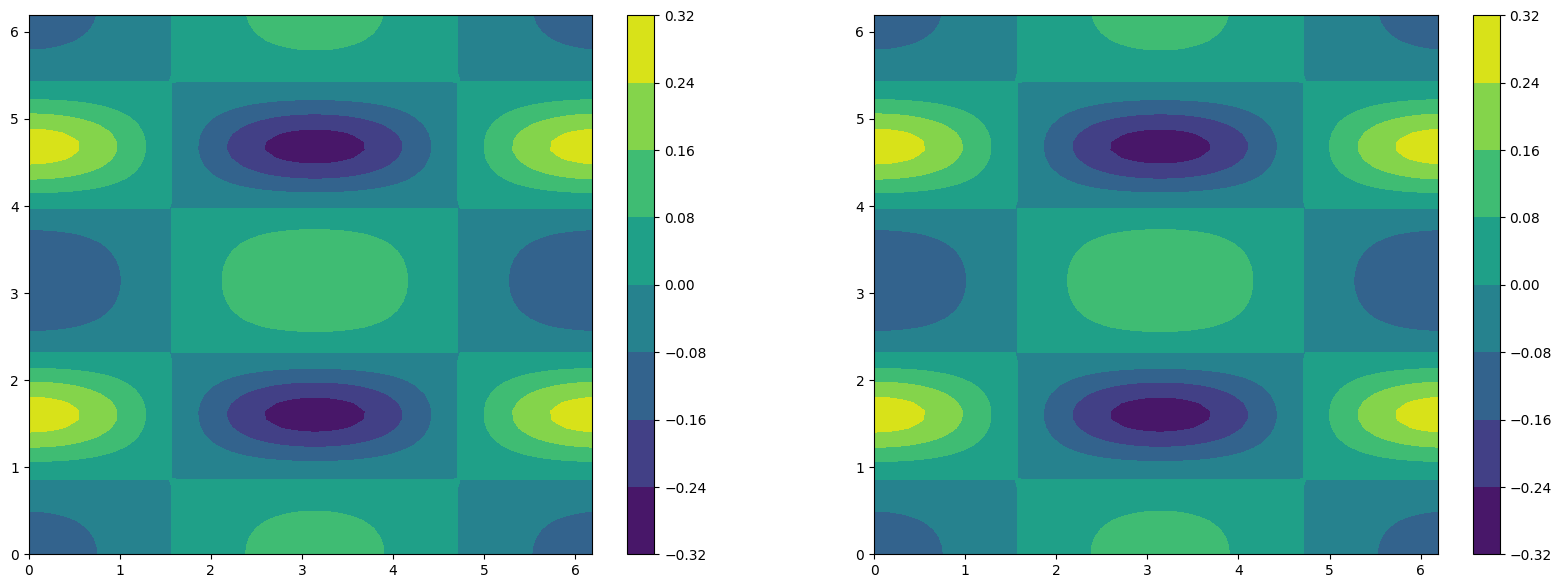

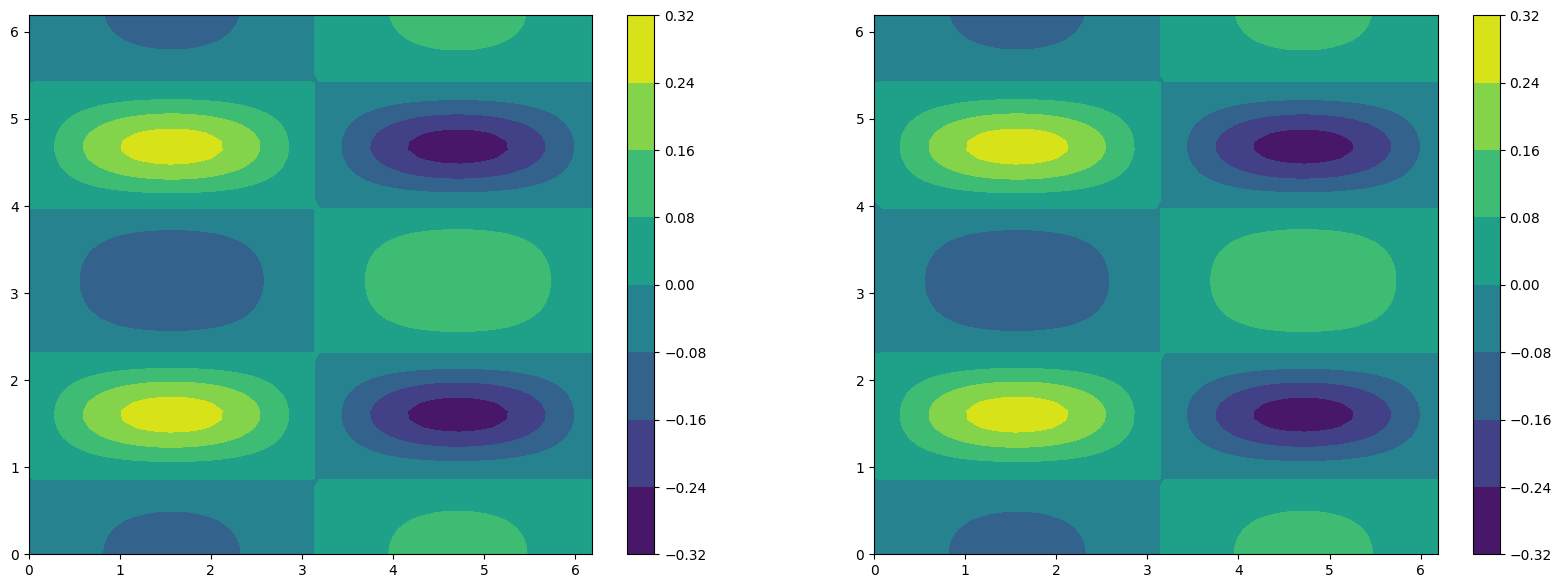

In [3]:
grad_phi = data["∇φ"]
fig, ax = plt.subplots(1,2,figsize=(20,7))
cmap = ax[0].contourf(grid.nodes[:,2].reshape(grid.num_zeta,grid.num_theta),grid.nodes[:,1].reshape(grid.num_zeta,grid.num_theta), grad_phi[:,0].reshape(grid.num_zeta, grid.num_theta))
plt.colorbar(cmap)
cmap2 = ax[1].contourf(grid.nodes[:,2].reshape(grid.num_zeta,grid.num_theta),grid.nodes[:,1].reshape(grid.num_zeta,grid.num_theta), B[:,0].reshape(grid.num_zeta, grid.num_theta))
plt.colorbar(cmap2)

fig, ax = plt.subplots(1,2,figsize=(20,7))
cmap = ax[0].contourf(grid.nodes[:,2].reshape(grid.num_zeta,grid.num_theta),grid.nodes[:,1].reshape(grid.num_zeta,grid.num_theta), grad_phi[:,1].reshape(grid.num_zeta, grid.num_theta))
plt.colorbar(cmap)
cmap2 = ax[1].contourf(grid.nodes[:,2].reshape(grid.num_zeta,grid.num_theta),grid.nodes[:,1].reshape(grid.num_zeta,grid.num_theta), B[:,1].reshape(grid.num_zeta, grid.num_theta))
plt.colorbar(cmap2)

#grad_phi.shape

Text(0.5, 1.0, 'Comparison of $B$ and $\\nabla \\Phi$ for coil field')

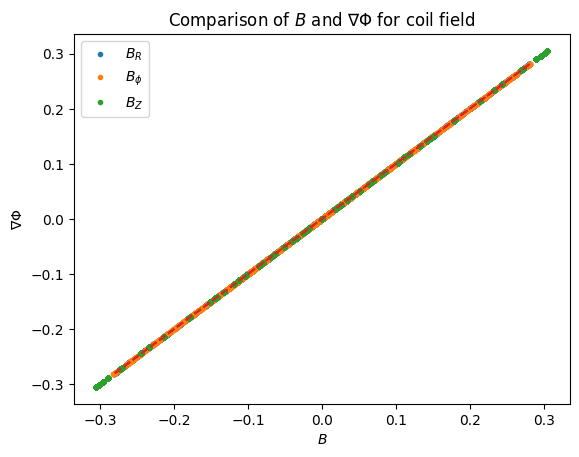

In [4]:
plt.plot(
    B,
    data["∇φ"],
    linestyle="",
    marker=".",
    label= ["$B_R$", "$B_\\phi$", "$B_Z$"],
)
plt.plot(
    B[:, 0],
    B[:, 0],
    linestyle="dashed",
    marker="",
)
plt.xlabel("$B$")
plt.ylabel("$\\nabla \\Phi$")
plt.legend()
plt.title(f"Comparison of $B$ and $\\nabla \\Phi$ for {field_type} field")

/Users/maya/anaconda3/envs/desc-env/lib/python3.12/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Users/maya/anaconda3/envs/desc-env/lib/python3.12/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))


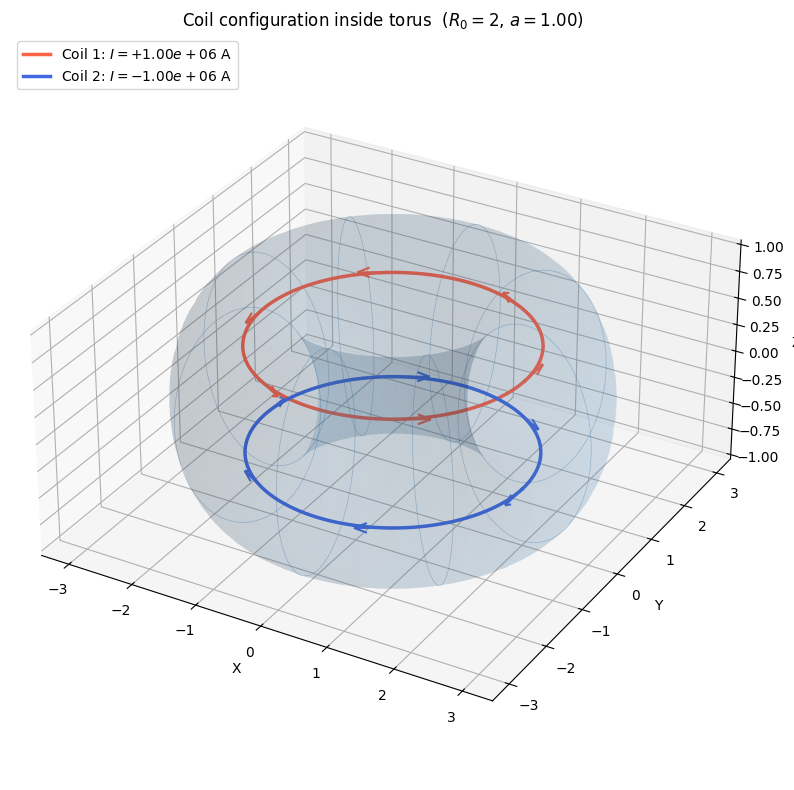

In [5]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# --- Torus surface (semi-transparent) ---
theta_s = np.linspace(0, 2 * np.pi, 80)
zeta_s  = np.linspace(0, 2 * np.pi, 80)
TT, ZZ = np.meshgrid(theta_s, zeta_s)
X_s = (R0 + a * np.cos(TT)) * np.cos(ZZ)
Y_s = (R0 + a * np.cos(TT)) * np.sin(ZZ)
Z_s = a * np.sin(TT)
ax.plot_surface(X_s, Y_s, Z_s, alpha=0.12, color="steelblue", linewidth=0, zorder=1)

# Draw a few meridional cross-section rings for reference
for zeta_0 in np.linspace(0, 2 * np.pi, 8, endpoint=False):
    X_ring = (R0 + a * np.cos(theta_s)) * np.cos(zeta_0)
    Y_ring = (R0 + a * np.cos(theta_s)) * np.sin(zeta_0)
    Z_ring = a * np.sin(theta_s)
    ax.plot(X_ring, Y_ring, Z_ring, color="steelblue", lw=0.5, alpha=0.4, zorder=2)

# --- Coils ---
phi_arr = np.linspace(0, 2 * np.pi, 400, endpoint=False)
colors = ["tomato", "royalblue"]
n_arrows = 6

for i in range(len(coil.coils)):
    c   = coil.coils[i]
    R_c = float(c.R_n[0])
    Z_c = float(c.Z_n[0])
    I_c = float(c.current)
    col = colors[i]

    X_c = R_c * np.cos(phi_arr)
    Y_c = R_c * np.sin(phi_arr)
    Z_c_arr = np.full_like(phi_arr, Z_c)

    ax.plot(X_c, Y_c, Z_c_arr, color=col, lw=2.5,
            label=f"Coil {i+1}: $I = {I_c:+.2e}$ A", zorder=5)

    # Arrows indicating current direction (sign flips tangent for negative I)
    sign = np.sign(I_c)
    for idx in np.linspace(0, len(phi_arr), n_arrows, endpoint=False, dtype=int):
        phi_0 = phi_arr[idx]
        scale = 0.25
        ax.quiver(
            R_c * np.cos(phi_0),
            R_c * np.sin(phi_0),
            Z_c,
            sign * (-R_c * np.sin(phi_0)) * scale,
            sign * ( R_c * np.cos(phi_0)) * scale,
            0,
            color=col, arrow_length_ratio=0.35, lw=1.5, zorder=6,
        )

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_box_aspect([1, 1, 0.5])
ax.legend(loc="upper left")
ax.set_title(f"Coil configuration inside torus  ($R_0={R0}$, $a={a:.2f}$)")
plt.tight_layout()
plt.show()


/var/folders/tp/dxlt_qgd63n_pj870vcq9wth0000gp/T/ipykernel_56515/1544809776.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


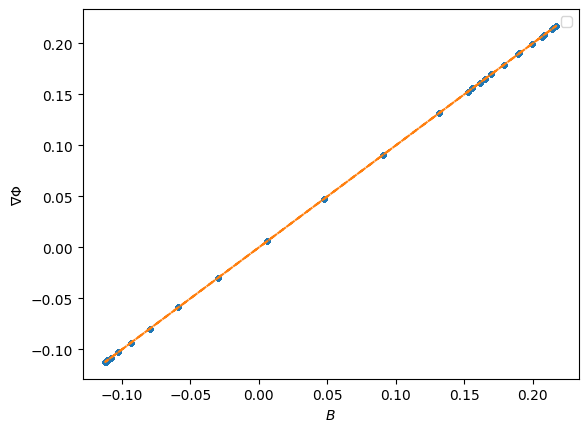

In [6]:
plt.plot(
    dot(B, data["n_rho"]),
    dot(data["∇φ"],data["n_rho"]),
    linestyle="",
    marker=".",
    #label= ["$B_R$", "$B_\\phi$", "$B_Z$"],
)
plt.plot(
    dot(B,data["n_rho"]),
    dot(B,data["n_rho"]),
    linestyle="dashed",
    marker="",
)
plt.xlabel("$B$")
plt.ylabel("$\\nabla \\Phi$")
plt.legend()

In [7]:
"""offset_surface = FourierRZToroidalSurface.from_shape_parameters(
    major_radius=R0,
    aspect_ratio=R0/(surface.compute("a")["a"] + 0.5),
    elongation=1,
    triangularity=0,
    squareness=0,
    eccentricity=0,
    torsion=0,
    twist=0,
    NFP=1,
    sym=True,
)

offset_data = offset_surface.compute(data_keys + ["R", "phi", "Z"], grid=grid, basis="xyz")
B_offset = coil.compute_magnetic_field(offset_data["x"], source_grid=LinearGrid(N=grid.N),basis="xyz")
offset_data["B0*n"] = -dot(B_offset, offset_data["n_rho"])
offset_data, RpZ_offset_data = field.compute(
    ["∇φ", "Phi", "x", "n_rho"],
    grid,
    #data=data,
    RpZ_data=offset_data,
    problem="exterior Neumann",
    on_boundary=False,
    maxiter=maxiter,
    full_output=True,
    chunk_size=chunk_size,
    basis="xyz",
    RpZ_grid=grid,

)
plt.plot(
    B_offset,
    RpZ_data["∇φ"],
    ".")
np.testing.assert_allclose(
    RpZ_data["∇φ"],
    B_offset,
    atol=1e-6,
)"""

'offset_surface = FourierRZToroidalSurface.from_shape_parameters(\n    major_radius=R0,\n    aspect_ratio=R0/(surface.compute("a")["a"] + 0.5),\n    elongation=1,\n    triangularity=0,\n    squareness=0,\n    eccentricity=0,\n    torsion=0,\n    twist=0,\n    NFP=1,\n    sym=True,\n)\n\noffset_data = offset_surface.compute(data_keys + ["R", "phi", "Z"], grid=grid, basis="xyz")\nB_offset = coil.compute_magnetic_field(offset_data["x"], source_grid=LinearGrid(N=grid.N),basis="xyz")\noffset_data["B0*n"] = -dot(B_offset, offset_data["n_rho"])\noffset_data, RpZ_offset_data = field.compute(\n    ["∇φ", "Phi", "x", "n_rho"],\n    grid,\n    #data=data,\n    RpZ_data=offset_data,\n    problem="exterior Neumann",\n    on_boundary=False,\n    maxiter=maxiter,\n    full_output=True,\n    chunk_size=chunk_size,\n    basis="xyz",\n    RpZ_grid=grid,\n\n)\nplt.plot(\n    B_offset,\n    RpZ_data["∇φ"],\n    ".")\nnp.testing.assert_allclose(\n    RpZ_data["∇φ"],\n    B_offset,\n    atol=1e-6,\n)'

In [8]:
from scipy.constants import mu_0

a = surface.compute(["a"], grid=grid, basis="xyz")["a"]

surf_jacobian = a * (R0 + a * np.cos(grid.nodes[:,1])) * grid.weights

W_phi = (1 / (2 * mu_0)) * (data["Phi"] * data["B0*n"] * surf_jacobian).sum()
W_phi

Array(588030.17547031, dtype=float64)

W_ext       = 5.070035e+05 J
Masked 31904 points with R < 0 (48.2%)
W_ext       = 5.522086e+05 J
Masked 72926 points with R < 0 (48.1%)
W_ext       = 5.723618e+05 J
Masked 166894 points with R < 0 (48.1%)
W_ext       = 5.811694e+05 J
Masked 381770 points with R < 0 (48.0%)
W_ext       = 5.850424e+05 J
Masked 876790 points with R < 0 (48.0%)
W_ext       = 5.867290e+05 J
Masked 2014246 points with R < 0 (48.0%)


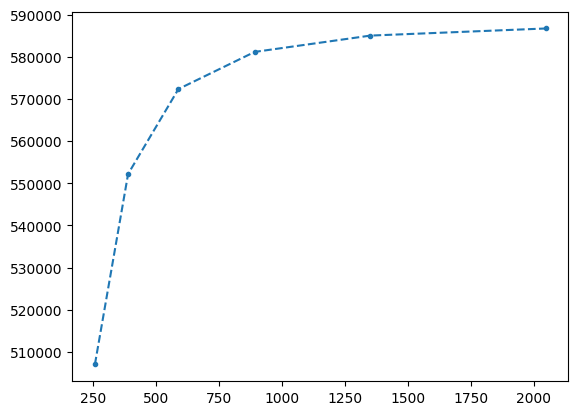

In [21]:
from desc.grid import QuadratureGrid
def compute_external_coil_energy(field, R0, a, L=200, M=200,
                                  r_max_factor=10.0, phi=0.0):
    """
    W = (2π/2μ₀) ∫∫_{r>a, R>0} B²(R,Z) · r(R₀ + r cosθ) dr dθ

    Grid in toroidal (r,θ) to trivially exclude the plasma interior (r < a),
    then mask R < 0 for large r near θ=π.
    """
    grid = QuadratureGrid(L=L, M=M, N=0)
    
    r_flat = grid.nodes[:,0] * r_max_factor + a
    t_flat = grid.nodes[:,1]
    #r_1d = r_flat.reshape()

    R_flat = R0 + r_flat * np.cos(t_flat)
    Z_flat = r_flat * np.sin(t_flat)

    # Only physical points (R > 0 required in cylindrical coords)
    valid = R_flat > 0
    R_v, Z_v, r_v, t_v = R_flat[valid], Z_flat[valid], r_flat[valid], t_flat[valid]

    coords = np.column_stack([R_v, np.full(valid.sum(), phi), Z_v])
    B = np.array(field.compute_magnetic_field(coords, basis="rpz", source_grid=LinearGrid(N=36)))
    B_sq = np.sum(B**2, axis=-1)

    # Compute integration weights
    jacobian = r_v * (R0 + r_v * np.cos(t_v))  # = r * R, always > 0 here
    jacobian = jacobian
    weights = grid.spacing[valid].prod(axis=-1) * r_max_factor # since dr = r_max drho

    # Integrate B^2
    W = (1 / (2 * mu_0)) * np.dot(B_sq, jacobian * weights)

    print(f"W_ext       = {W:.6e} J")
    print(f"Masked {(~valid).sum()} points with R < 0 ({100*(~valid).mean():.1f}%)")
    return W


Ws = []
resolutions = np.logspace(8,11,base=2,num=6,dtype=int)
for res in resolutions:
    W = compute_external_coil_energy(coil, R0, a, r_max_factor=1000, L=res, M=res)
    Ws.append(W)

plt.plot(resolutions, Ws, linestyle='dashed', marker=".")

Estimated power law exponent: -3.76 (should be close to -3 for a quadrupole field)


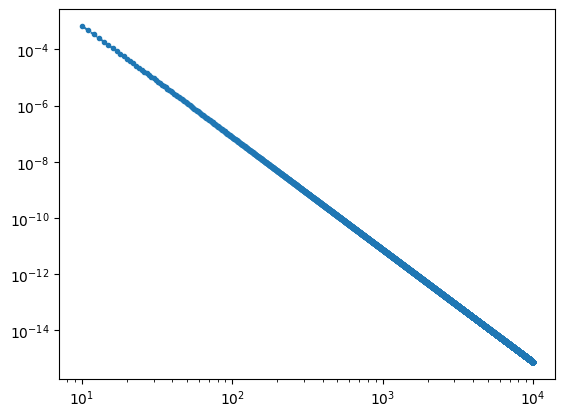

In [10]:
from sklearn.linear_model import LinearRegression
n_points = 10000
x = np.vstack([np.zeros(n_points),np.zeros(n_points),np.linspace(10,10000,n_points)])
field = coil.compute_magnetic_field(x.T, source_grid=LinearGrid(N=1000), basis="xyz")
plt.loglog(x[2], field[:,2], linestyle="dashed", marker=".")

model = LinearRegression(fit_intercept=False)
model.fit(np.log(x[2][:, np.newaxis]), np.log(field[:, 2]))
print(f"Estimated power law exponent: {model.coef_[0]:.2f} (should be close to -3 for a quadrupole field)")

In [11]:
x.T

array([[    0.        ,     0.        ,    10.        ],
       [    0.        ,     0.        ,    10.99909991],
       [    0.        ,     0.        ,    11.99819982],
       ...,
       [    0.        ,     0.        ,  9998.00180018],
       [    0.        ,     0.        ,  9999.00090009],
       [    0.        ,     0.        , 10000.        ]], shape=(10000, 3))

In [12]:
coil

CoilSet at 0x15a24bef0 (name=, with 2 submembers)

In [13]:
W_analytic = (1/2 * mu_0 * R0 * coil.current**2 * (np.log(8 * R0/a) - 2))
W_analytic

TypeError: unsupported operand type(s) for ** or pow(): 'list' and 'int'

In [26]:
d = coil[0].Z_n - coil[1].Z_n
W_dipole = (1/2 * mu_0 * R0 * coil[0].current**2 * (np.log(d/a)))
W_dipole

Array([-0.01151445], dtype=float64)

In [60]:

def compute_external_coil_energy_3d(R0, a, nr=100, ntheta=100, nzeta=50,
                                     NFP=1, r_max_factor=10.0):
    """
    Non-axisymmetric external magnetic energy.

    W = (NFP/2μ₀) ∫_0^{2π/NFP} ∫_0^{2π} ∫_a^{r_max}
            B²(r,θ,φ) · r(R₀ + r cosθ) dr dθ dφ

    Grid in toroidal (r,θ,φ): inner boundary r=a requires no masking,
    R<0 points (near θ=π, large r) are excluded.
    """
    r_1d = np.linspace(a, r_max_factor * a, nr)
    t_1d = np.linspace(0, 2 * np.pi, ntheta, endpoint=False)
    z_1d = np.linspace(0, 2 * np.pi / NFP, nzeta, endpoint=False)
    dr = r_1d[1] - r_1d[0]
    dt = t_1d[1] - t_1d[0]
    dz = z_1d[1] - z_1d[0]

    rr, tt, zz = np.meshgrid(r_1d, t_1d, z_1d, indexing="ij")
    r_flat = rr.ravel()
    t_flat = tt.ravel()
    z_flat = zz.ravel()

    R_flat = R0 + r_flat * np.cos(t_flat)
    Z_flat = r_flat * np.sin(t_flat)

    valid = R_flat > 0
    coords = np.column_stack([R_flat[valid], z_flat[valid], Z_flat[valid]])

    B = np.array(_grad_G(coords - x0))
    B_sq = np.sum(B**2, axis=-1)

    jacobian = r_flat[valid] * (R0 + r_flat[valid] * np.cos(t_flat[valid]))

    W = NFP / (2 * mu_0) * np.dot(B_sq, jacobian) * dr * dt * dz

    outer = r_flat[valid] > r_1d[-1] - dr
    W_outer = NFP / (2 * mu_0) * np.dot(B_sq[outer], jacobian[outer]) * dr * dt * dz
    print(f"W_ext       = {W:.6e} J")
    print(f"Outer shell = {W_outer:.3e} J  ({100*W_outer/W:.2f}% — truncation estimate)")
    print(f"Grid: {nr}×{ntheta}×{nzeta} = {nr*ntheta*nzeta} pts, "
          f"{valid.sum()} valid, {(~valid).sum()} masked (R<0)")
    return W
compute_external_coil_energy_3d(R0, a, r_max_factor=100)


W_ext       = 4.492640e+04 J
Outer shell = 3.258e+00 J  (0.01% — truncation estimate)
Grid: 100×100×50 = 500000 pts, 266850 valid, 233150 masked (R<0)


np.float64(44926.403361765195)